# Evaluating Classification Models

## Objectives


After completing this lab, you will be able to:

* Implement and evaluate the performance of classification models on real-world data
* Interpret and compare various evaluation metrics and the confusion matrix for each model

## Introduction
In this lab, you will:
- Use the breast cancer data set included in scikit-learn to predict whether a tumor is benign or malignant
- Create two classification models and evaluate them. 
- Add some Gaussian random noise to the features to simulate measurement errors
 
Interpreting and comparing the various evaluation metrics and the confusion matrix for each model will provide you with some valuable intuition regarding what the evaluation metrics mean and how they might impact your interpretation of the model performances.

Your goal in this lab is **not** to find the best classifier - it is primarily intended for you to practice interpreting and comparing results in the context of a real-world problem.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


### Load the Breast Cancer data set


In [3]:
df = load_breast_cancer()


In [6]:
x = df.data
y = df.target
feature_names = df.feature_names
print(f"data:\n #{x}")
print(f"target:\n #{y}")
print(f"feature names:\n #{feature_names}")

data:
 #[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]
target:
 #[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 

### Print the description of the Breast Cancer data set


In [8]:
print(df.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In summary, each observation in the data set consists of a variety attributes measured from a sample of cells from a suspicious mass taken from a patient. 
The goal is to predict whether a mass is malignant (positive case) or benign (negative case):


In [9]:
print(df.target_names)

['malignant' 'benign']


### Standardize the Dataset

In [11]:
scaler = StandardScaler()
x_scale = scaler.fit_transform(x)
print("scaled x data: \n", x_scale)

scaled x data: 
 [[ 1.09706398 -2.07333501  1.26993369 ...  2.29607613  2.75062224
   1.93701461]
 [ 1.82982061 -0.35363241  1.68595471 ...  1.0870843  -0.24388967
   0.28118999]
 [ 1.57988811  0.45618695  1.56650313 ...  1.95500035  1.152255
   0.20139121]
 ...
 [ 0.70228425  2.0455738   0.67267578 ...  0.41406869 -1.10454895
  -0.31840916]
 [ 1.83834103  2.33645719  1.98252415 ...  2.28998549  1.91908301
   2.21963528]
 [-1.80840125  1.22179204 -1.81438851 ... -1.74506282 -0.04813821
  -0.75120669]]


### Add some noise
Next, add some noise to simulate random measurement error, then view the first few rows of the original and noisy features for comparison.


In [12]:
#Add gausian noise to datset
np.random.seed(42) # for reproducibility
noise_factor =0.5 # to control the noise amount of the dataset
x_noisy = x_scale + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x.shape)

#get original and nosiy datasets for seperate dataframes to comparison
df_original = pd.DataFrame(x_scale, columns=feature_names)
df_noisy = pd.DataFrame(x_noisy, columns=feature_names)

In [14]:
# print the the df_original
print("original dataset:\n", df_original.head())


original dataset:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0     1.097064     -2.073335        1.269934   0.984375         1.568466   
1     1.829821     -0.353632        1.685955   1.908708        -0.826962   
2     1.579888      0.456187        1.566503   1.558884         0.942210   
3    -0.768909      0.253732       -0.592687  -0.764464         3.283553   
4     1.750297     -1.151816        1.776573   1.826229         0.280372   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0          3.283515        2.652874             2.532475       2.217515   
1         -0.487072       -0.023846             0.548144       0.001392   
2          1.052926        1.363478             2.037231       0.939685   
3          3.402909        1.915897             1.451707       2.867383   
4          0.539340        1.371011             1.428493      -0.009560   

   mean fractal dimension  ...  worst radius  worst texture  worst perime

In [15]:
# print the nosiy dataset
print("noisy dataset:\n", df_noisy.head())

noisy dataset:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0     1.345421     -2.142467        1.593778   1.745890         1.451390   
1     1.528967      0.572507        1.679206   1.379853        -0.415690   
2     1.340301      0.363357        1.013336   0.960780         1.348473   
3    -0.720371      0.738055       -0.943714  -0.928295         3.087499   
4     2.145813     -1.606510        2.477970   1.125304         0.573800   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0          3.166446        3.442480             2.916193       1.982778   
1         -1.097493        0.080586            -0.431691      -0.662701   
2          1.731046        1.327473             2.538997       1.120503   
3          2.671152        2.063957             1.582235       2.869940   
4          1.634568        0.875743             1.145344       0.040265   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter

### Visualizing the noise content. 
You can get a good idea of how much noise there is in the features by comparing values in the previous tables. You can also visualize the differences in several ways.
Let's begin by plotting the histograms of one of the features with and without noise for comparison.
#### Histograms


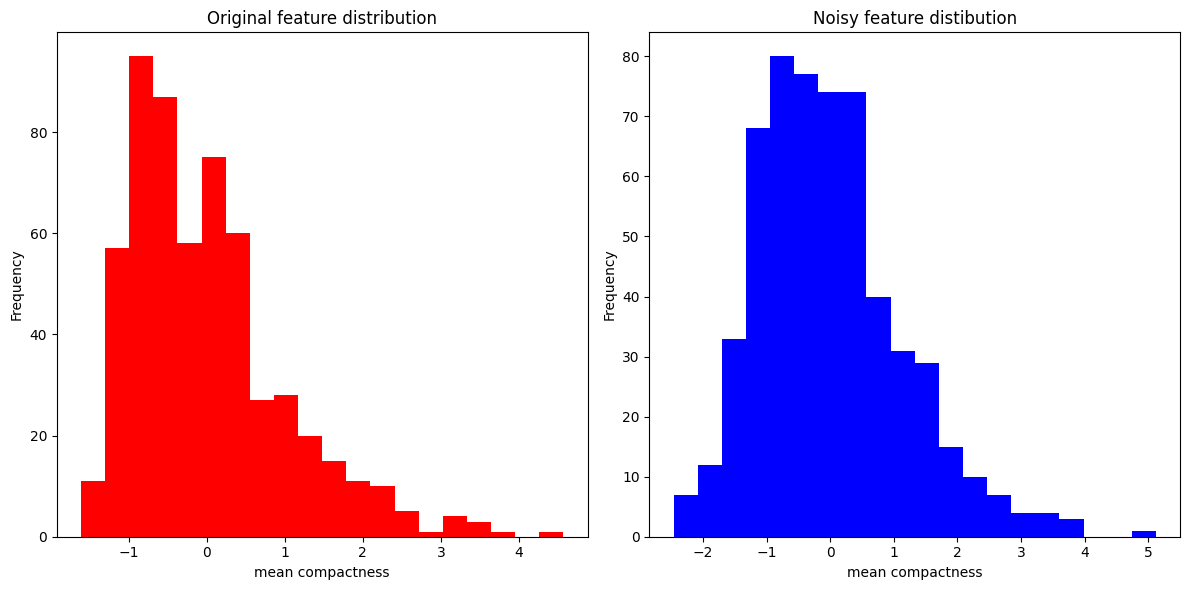

In [16]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.hist(df_original[feature_names[5]], bins=20, label="Original", color='red')
plt.title("Original feature distribution")
plt.xlabel(feature_names[5])
plt.ylabel("Frequency")


plt.subplot(1,2,2)
plt.hist(df_noisy[feature_names[5]], bins=20, label="Noisy", color="blue")
plt.title("Noisy feature distibution")
plt.xlabel(feature_names[5])
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
